## Preprocessing the Dataset.


In [1]:
# Importing the libraries.
import numpy as np
import pandas as pd

In [2]:
# Load the dataset.
df = pd.read_csv("/content/churn-bigml-20.csv")

In [3]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [5]:
print(df.shape)

(667, 20)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

In [7]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,8.407796,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718
std,40.819480,41.783305,13.994480,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357
min,1.000000,408.000000,0.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,0.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000
50%,102.000000,415.000000,0.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000
75%,128.000000,415.000000,20.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000
max,232.000000,510.000000,51.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000


🔑 Key Insights
- Voicemail is rarely used (median = 0).
- Daytime usage is the highest contributor to charges (~$30.76 vs. $17.29 evening, $8.99 night).
- International usage is minimal compared to domestic.
- Customer service calls are low overall, but a few customers are heavy users (up to 8).
- Area codes are concentrated around 408 and 415, suggesting regional clustering.


In [8]:
# Checking the missing values in the data.
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


## It (scaling).

In [11]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = df.drop(columns=["State","Area code","Churn"])

# Convert categorical Yes/No to 0/1
features = features.replace({"Yes":1,"No":0})

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

/tmp/ipython-input-1331967347.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features = features.replace({"Yes":1,"No":0})


## Apply K-Means clustering and determine the optimal number of clusters using the elbow method.

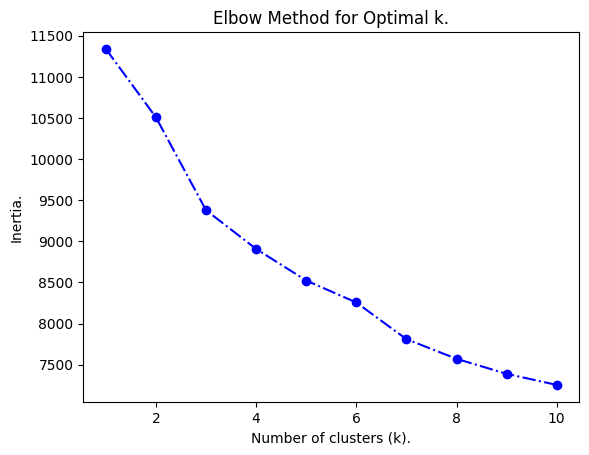

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve.
plt.plot(K, inertia, 'bo-.')
plt.xlabel('Number of clusters (k).')
plt.ylabel('Inertia.')
plt.title('Elbow Method for Optimal k.')
plt.show()

## Visualize clusters using 2D scatter plots.

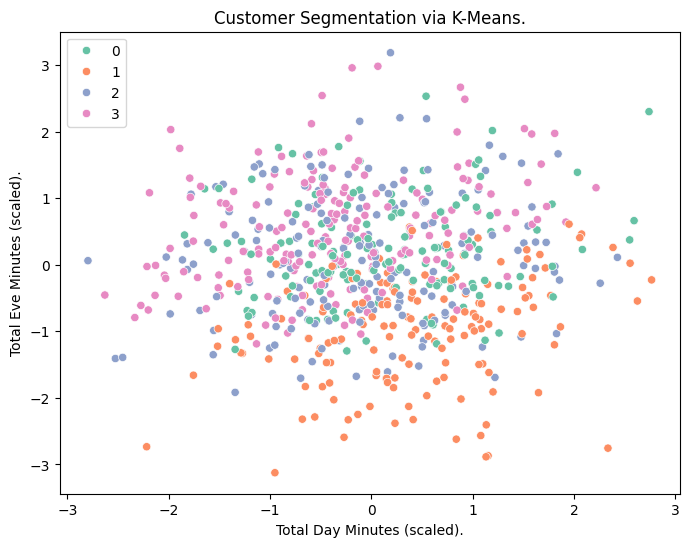

In [13]:
# Fit with chosen k.
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe.
df["Cluster"] = clusters

# Example visualization: Day Minutes vs Eve Minutes.
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,6], y=X_scaled[:,9], hue=clusters, palette="Set2")
plt.xlabel("Total Day Minutes (scaled).")
plt.ylabel("Total Eve Minutes (scaled).")
plt.title("Customer Segmentation via K-Means.")
plt.show()

## Interpret the clustering results.

In [15]:
# Create a copy of the DataFrame to modify for summary purposes
df_summary = df.copy()

# Convert categorical 'Yes'/'No' columns to 1/0
df_summary['International plan'] = df_summary['International plan'].map({'Yes': 1, 'No': 0})
df_summary['Voice mail plan'] = df_summary['Voice mail plan'].map({'Yes': 1, 'No': 0})

# Convert boolean 'Churn' column to integer 1/0
df_summary['Churn'] = df_summary['Churn'].astype(int)

# Drop 'State' and 'Area code' columns as their mean is not informative
# 'Area code' is an integer, but functionally it's a categorical identifier.
cluster_summary = df_summary.drop(columns=['State', 'Area code']).groupby("Cluster").mean()
print(cluster_summary)

         Account length  International plan  Voice mail plan  \
Cluster                                                        
0            106.643836            0.136986         0.027397   
1            101.928105            0.071895         0.032680   
2            102.815642            0.089385         1.000000   
3            100.666667            0.031746         0.005291   

         Number vmail messages  Total day minutes  Total day calls  \
Cluster                                                              
0                     0.527397         189.409589        99.191781   
1                     0.607843         203.528105       101.875817   
2                    30.229050         174.779888       100.005587   
3                     0.142857         161.974603       102.407407   

         Total day charge  Total eve minutes  Total eve calls  \
Cluster                                                         
0               32.200616         214.658219       100.582192   

 Key Insights
- Cluster 2 is the most stable group (low churn, high voicemail adoption).
- Cluster 3 shows the highest churn risk despite moderate service calls — possibly due to unmet needs in evening/night usage.
- Clusters 0 & 1 have similar churn (~16%) but differ in usage intensity (Cluster 1 heavier).
- International plan adoption is low across all clusters (<14%), suggesting untapped potential for global calling packages.


🚀 Business Impact
- Retention focus: Clusters 0 & 3 (higher churn).
- Upselling opportunities: Cluster 2 (loyal voicemail users).
- New product design: Night-time bundles for Cluster 3, international packages for all clusters.


/tmp/ipython-input-2974268516.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary[feature], ax=axes[i], palette='viridis')
/tmp/ipython-input-2974268516.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary[feature], ax=axes[i], palette='viridis')
/tmp/ipython-input-2974268516.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary[feature], ax=axes[i], palette='viridis')
/tmp/ipython-input-2974268516.py:21: FutureWar

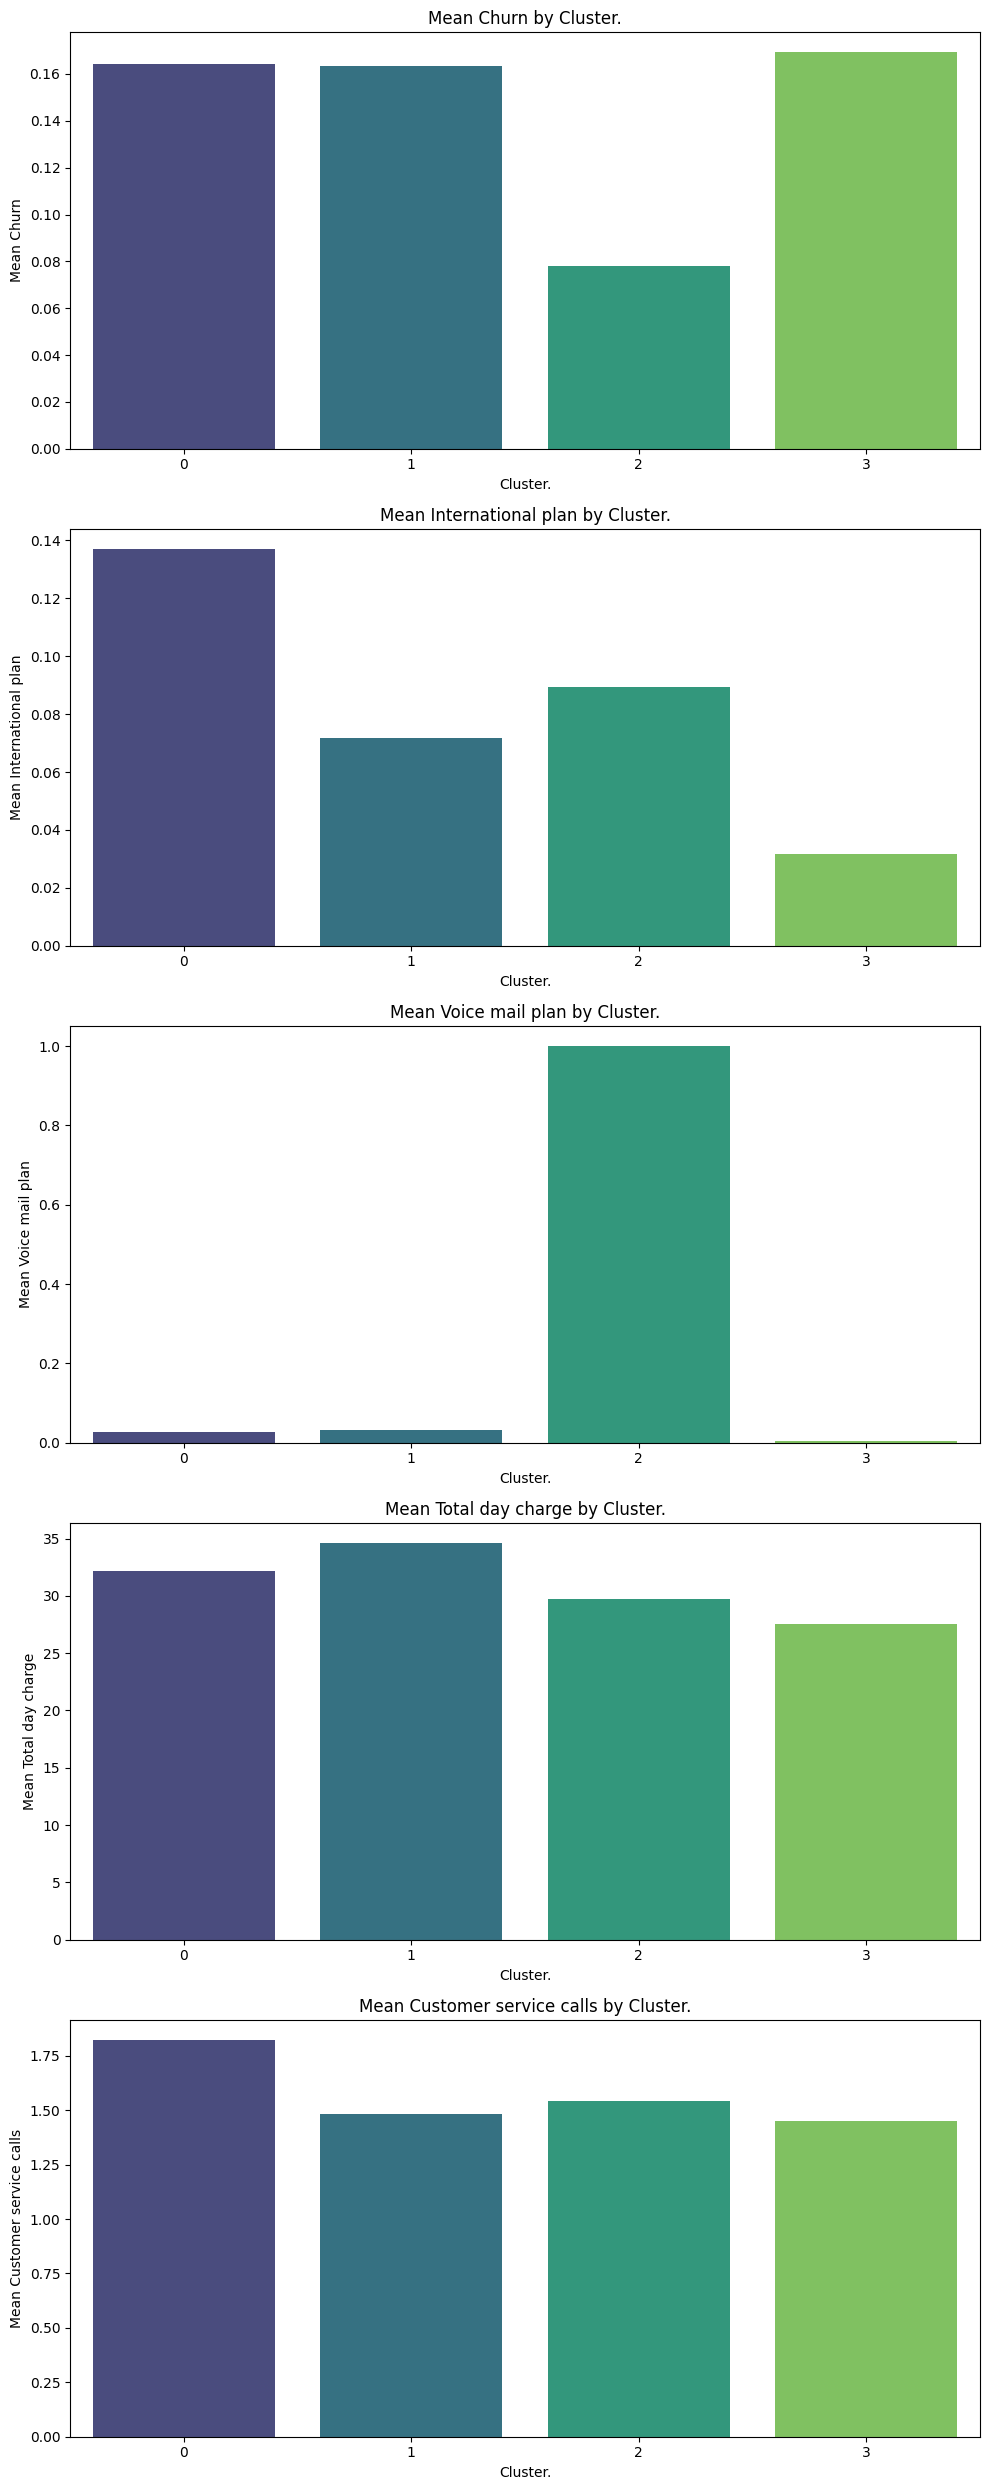

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few key features to visualize for comparison across clusters.
features_to_visualize = [
    'Churn',
    'International plan',
    'Voice mail plan',
    'Total day charge',
    'Customer service calls'
]

# Create a figure to hold multiple subplots.
fig, axes = plt.subplots(nrows=len(features_to_visualize), ncols=1, figsize=(10, 5 * len(features_to_visualize)))

# Flatten axes array for easy iteration if there's only one column.
if len(features_to_visualize) == 1:
    axes = [axes]

for i, feature in enumerate(features_to_visualize):
    sns.barplot(x=cluster_summary.index, y=cluster_summary[feature], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Mean {feature} by Cluster.')
    axes[i].set_xlabel('Cluster.')
    axes[i].set_ylabel(f'Mean {feature}')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()